### Library Imports

This notebook performs exploratory analysis and feature preparation for modeling home sale prices.

Core libraries used:

- **pandas / numpy** → data manipulation
- **matplotlib / seaborn** → visualization
- **seaborn styling** improves readability of exploratory plots

Display settings are adjusted to show all columns during analysis.

In [1]:
# Core analysis libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Improve plot styling
sns.set()

# Show all columns during EDA
pd.set_option('display.max_columns', None)

In [2]:
# File path locations
from pathlib import Path

# File paths
PROJECT_ROOT = Path.cwd().resolve().parent
CLEAN_DATA_DIR = PROJECT_ROOT / "data/clean_data"
RAW_DATA_DIR = PROJECT_ROOT / "data/raw_data"
MODELS_DIR = PROJECT_ROOT / "models"
SRC_DIR = PROJECT_ROOT / "src"
DEPLOYMENT_DIR = PROJECT_ROOT / "deployment"

In [3]:
# Load cleaned dataset produced from preprocessing pipeline.
# Pipe delimiter used due to text export from earlier step
data = pd.read_parquet(CLEAN_DATA_DIR / "01_preprocessing.parquet")
data.head()

,borough_x,neighborhood,building_class_category,tax_class_at_present,block,lot,building_class_at_present,address,apartment_number,zip_code,residential_units,commercial_units,total_units,land_square_feet,gross_square_feet,year_built,tax_class_at_time_of_sale,building_class_at_time_of_sale,sale_price,sale_date,build_age_yrs,BBL,borough_y,latitude,longitude,nearest_station,distance_to_station
0,3,BATH BEACH,01 ONE FAMILY DWELLINGS,1,6364,72,A5,68 BAY 14TH STREET,None,11214,1,0,1,1950,972,1950,1,A5,860000,2025-11-24,76,3063640072,BK,40.607931,-74.007289,153,0.291308
1,3,BATH BEACH,01 ONE FAMILY DWELLINGS,1,6372,39,A9,86-29 19 AVENUE,None,11214,1,0,1,2417,1944,1930,1,A9,1180000,2025-11-19,96,3063720039,BK,40.605178,-74.000846,108,0.146919
2,3,BATH BEACH,01 ONE FAMILY DWELLINGS,1,6401,46,A1,144 BAY 17 STREET,None,11214,1,0,1,4833,2164,1925,1,A1,1300000,2025-01-13,101,3064010046,BK,40.604878,-74.006706,153,0.336323
3,3,BATH BEACH,01 ONE FAMILY DWELLINGS,1,6431,15,A9,221 BAY 13 STREET,None,11214,1,0,1,1530,2484,1920,1,A9,900000,2025-10-20,106,3064310015,BK,40.605037,-74.010865,153,0.519558
4,3,BATH BEACH,01 ONE FAMILY DWELLINGS,1,6431,56,A5,200 BAY 14 STREET,None,11214,1,0,1,2086,1458,1910,1,A5,930000,2025-02-05,116,3064310056,BK,40.605227,-74.010127,153,0.478792


In [4]:
# Inspect dataset size after preprocessing
# Helps verify row counts before additional filtering
data.shape

(8229, 27)

### Target Variable Preparation

Sale price is the primary prediction target.

Two preprocessing steps are applied:

1. **Remove extreme low values (< $1,000)**  
   These are typically data entry errors or non-arms-length transactions.

2. **Log-transform sale price**  
   Real estate prices are heavily right-skewed.  
   Log transformation helps:

- stabilize variance
- reduce influence of extreme prices
- improve performance of regression models

In [5]:
# Remove extremely low sale prices which are likely recording errors or non-market transactions
data = data[data["sale_price"] > 1000].copy()

In [6]:
# Apply log10 transformation to reduce right skew in housing prices. 
# This improves model stability and helps linear models fit better
data["log_sale_price"] = np.log10(data["sale_price"])

### Property Size Feature

Gross square footage is a key driver of housing price.

This section:

- removes invalid square footage values
- applies log transformation
- evaluates relationship between property size and price

In [7]:
# Remove observations with missing or zero square footage
# These cannot produce valid price-per-square-foot metrics
data = data[(data["gross_square_feet"] > 0) & (data["gross_square_feet"].notna())].copy()
data.shape

(5731, 28)

In [8]:
# Log-transform property size to linearize relationship with price
data["log_gross_sqft"] = np.log10(data["gross_square_feet"])

In [9]:
# Check revised data's descriptive statistics
data[["log_gross_sqft", "gross_square_feet"]].describe()

,log_gross_sqft,gross_square_feet
count,5731.000000,5731.000000
mean,3.365623,3099.673006
std,0.246327,6662.496659
min,2.722634,528.000000
25%,3.209515,1620.000000
50%,3.346353,2220.000000
75%,3.482302,3036.000000
max,5.271328,186779.000000


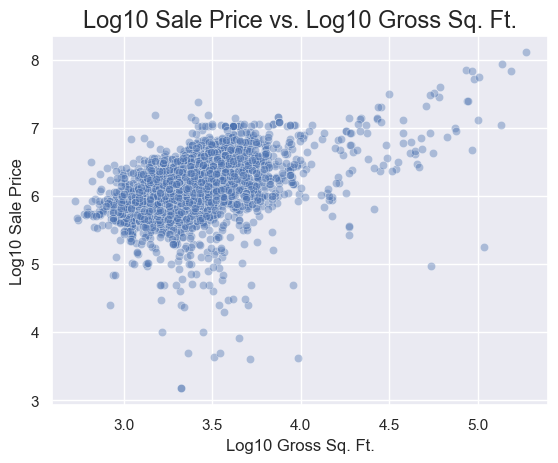

In [10]:
# Examine relationship between property size and sale price
# Log–log scale helps reveal linear relationships and reduce skew effects
sns.scatterplot(
    data=data, 
    x="log_gross_sqft", 
    y="log_sale_price",
    alpha=0.4
)
plt.title("Log10 Sale Price vs. Log10 Gross Sq. Ft.", fontsize=17)
plt.xlabel("Log10 Gross Sq. Ft.")
plt.ylabel("Log10 Sale Price")
plt.show()

In [11]:
# Examine extreme property sizes using high percentiles
# Large luxury properties can distort model training
pd.DataFrame(data["gross_square_feet"].quantile([0.99, 0.995, 0.999]).astype(int))\
.rename(columns={"gross_square_feet":"Gross Sq. Ft."}).rename_axis("Percentile")

,Gross Sq. Ft.
Percentile,
0.990,20414
0.995,44122
0.999,100585


In [12]:
# Remove extreme outliers above the 99.5th percentile
# These are rare luxury properties that could distort model training
sqft_pctl = data["gross_square_feet"].quantile(0.995)

data = data[data["gross_square_feet"] < sqft_pctl].copy()
data.shape

(5702, 29)

In [13]:
# Descriptive statistics for "gross_square_feet" with percentile cut
pd.DataFrame(data["gross_square_feet"].describe().round(2))

,gross_square_feet
count,5702.00
mean,2700.90
std,2612.73
min,528.00
25%,1618.50
50%,2209.00
75%,3019.00
max,44100.00


### Price Per Square Foot Analysis

Price per square foot is a commonly used real estate valuation metric.

While not necessarily used directly as a model feature, it helps:

- identify pricing anomalies
- detect potential outliers
- understand market price distribution

In [14]:
# Calculate price per square foot as an exploratory metric
data["price_sqft"] = data["sale_price"] / data["gross_square_feet"]
pd.DataFrame(data["price_sqft"].describe().round(2))

,price_sqft
count,5702.00
mean,667.90
std,472.42
min,0.44
25%,409.34
50%,577.98
75%,800.00
max,10333.33


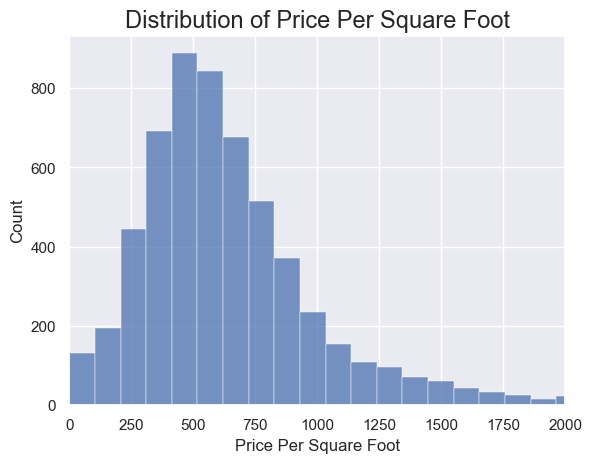

In [15]:
# Inspect distribution of price per square foot
# Used to identify extreme property valuations
sns.histplot(data["price_sqft"], bins=100)
plt.xlim(0, 2000)
plt.xlabel("Price Per Square Foot")
plt.title("Distribution of Price Per Square Foot", fontsize=17)
plt.show()

In [16]:
# Identify outliers on higher end
pd.DataFrame(data["price_sqft"].quantile([0.95, 0.99, 0.995, 0.999]).round(2)).rename_axis("Quantile")

,price_sqft
Quantile,
0.950,1432.28
0.990,2342.62
0.995,2690.93
0.999,5161.10


In [17]:
# Identify outliers on lower end
pd.DataFrame(data["price_sqft"].quantile([0.01, 0.05, 0.10]).round(2)).rename_axis("Quantile")

,price_sqft
Quantile,
0.01,45.13
0.05,188.00
0.10,270.85


In [18]:
lower_tail = data["price_sqft"].quantile(0.01)
upper_tail = data["price_sqft"].quantile(0.995)

In [19]:
data = data[(data["price_sqft"] >= lower_tail) & (data["price_sqft"] <= upper_tail)].copy()
data.shape

(5615, 30)

In [20]:
mask = (data["price_sqft"] >= lower_tail) & (data["price_sqft"] <= upper_tail)

In [21]:
print("Rows removed:", len(data) - mask.sum())
print("Percent removed:", (len(data) - mask.sum()) / len(data))

Rows removed: 0
Percent removed: 0.0


### Subway Station Distance

Access to public transportation is a key driver of property values in dense urban markets such as New York City.

To capture this effect, we compute the **distance from each property to the nearest subway station**.

Methodology:
- Geographic coordinates were used to represent property locations.
- Subway station coordinates were obtained from publicly available transit datasets.
- A nearest-neighbor search was performed to identify the closest station for each property.
- Distance was calculated using geographic coordinate distance.

This feature captures **transportation accessibility**, which often correlates with higher demand and property values.

In [22]:
# Boolean column if station is within half a mile
data["within_half_mi"] = (data["distance_to_station"] <= 0.5).astype(int)
data["within_half_mi"].value_counts()

within_half_mi
1    4107
0    1508
Name: count, dtype: int64

In [23]:
# Log distance_to_station
data["log_dist_to_station"] = np.log10(data["distance_to_station"])

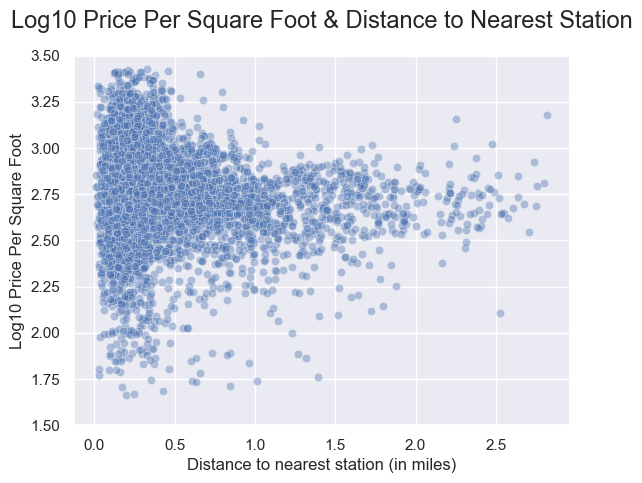

In [24]:
# Scatterplot
sns.scatterplot(data=data, x=data["distance_to_station"], y=np.log10(data["price_sqft"]), alpha=0.4)
plt.title("Log10 Price Per Square Foot & Distance to Nearest Station", fontsize=17, pad=20)
plt.xlabel("Distance to nearest station (in miles)")
plt.ylim(1.5, 3.5)
plt.ylabel("Log10 Price Per Square Foot")
plt.show()

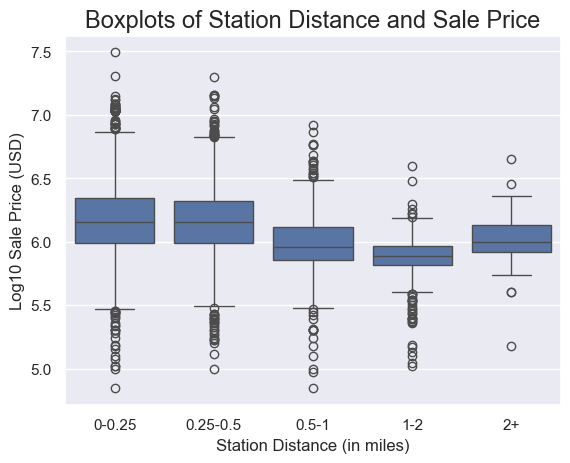

In [25]:
# Binned boxplots
bins = [0, 0.25, 0.5, 1, 2, 5]
labels = ["0-0.25", "0.25-0.5", "0.5-1", "1-2", "2+"]

data["station_distance_bucket"] = pd.cut(
    data["distance_to_station"],
    bins=bins,
    labels=labels
)

sns.boxplot(x="station_distance_bucket", y=data["log_sale_price"], data=data)
plt.title("Boxplots of Station Distance and Sale Price", fontsize=17)
plt.xlabel("Station Distance (in miles)")
plt.ylabel("Log10 Sale Price (USD)")
plt.show()

In [26]:
# Correlation of station distance and price
data[["distance_to_station", "log_sale_price"]].corr()

,distance_to_station,log_sale_price
distance_to_station,1.000000,-0.299753
log_sale_price,-0.299753,1.000000


### Neighborhood

Neighborhood is one of the strongest predictors of housing prices.

Properties located in different neighborhoods often reflect differences in:

- local amenities
- school quality
- transit access
- market demand

The `neighborhood` variable is treated as a **categorical feature** representing the geographic submarket in which the property is located.

During modeling, categorical encoding techniques are applied to incorporate neighborhood-level price variation into the model.

In [27]:
# Make neighborhood names consistent
data["neighborhood"] = (data["neighborhood"].str.strip()
                        .str.lower()
                        .str.replace(" ", "_")
                        .str.replace("-", "_")
)

In [28]:
# Count of neighborhoods
neighborhood_counts = data["neighborhood"].value_counts()
neighborhood_counts

neighborhood
bedford_stuyvesant          363
east_new_york               335
flatbush_east               304
canarsie                    296
borough_park                284
bensonhurst                 206
bushwick                    204
bay_ridge                   202
gravesend                   196
marine_park                 180
sheepshead_bay              176
crown_heights               174
sunset_park                 167
ocean_parkway_north         135
midwood                     134
flatbush_central            129
madison                     118
dyker_heights               117
flatbush_north              116
ocean_hill                  110
park_slope                  106
cypress_hills                99
old_mill_basin               94
bath_beach                   87
brownsville                  83
ocean_parkway_south          76
greenpoint                   76
bergen_beach                 70
williamsburg_east            66
flatlands                    59
clinton_hill               

In [29]:
# Remove neighborhoods with less than 10 properties
data = data[data["neighborhood"].map(neighborhood_counts) >= 10].copy()
data.shape

(5597, 33)

### Building Class Category

Building class describes the structural type of the property.

Examples include:
- single-family homes
- multi-family buildings
- condominiums

Different building types have fundamentally different price structures and market dynamics.

To incorporate this information, building classes were grouped into broader **building class categories**, allowing the model to capture structural differences while reducing feature sparsity.

In [30]:
# Remove number and whitespace from "building_class_category"
data["building_class_category"] = data["building_class_category"].str[3:]

In [31]:
data.head()

,borough_x,neighborhood,building_class_category,tax_class_at_present,block,lot,building_class_at_present,address,apartment_number,zip_code,residential_units,commercial_units,total_units,land_square_feet,gross_square_feet,year_built,tax_class_at_time_of_sale,building_class_at_time_of_sale,sale_price,sale_date,build_age_yrs,BBL,borough_y,latitude,longitude,nearest_station,distance_to_station,log_sale_price,log_gross_sqft,price_sqft,within_half_mi,log_dist_to_station,station_distance_bucket
0,3,bath_beach,ONE FAMILY DWELLINGS,1,6364,72,A5,68 BAY 14TH STREET,None,11214,1,0,1,1950,972,1950,1,A5,860000,2025-11-24,76,3063640072,BK,40.607931,-74.007289,153,0.291308,5.934498,2.987666,884.773663,1,-0.535648,0.25-0.5
1,3,bath_beach,ONE FAMILY DWELLINGS,1,6372,39,A9,86-29 19 AVENUE,None,11214,1,0,1,2417,1944,1930,1,A9,1180000,2025-11-19,96,3063720039,BK,40.605178,-74.000846,108,0.146919,6.071882,3.288696,606.995885,1,-0.832923,0-0.25
2,3,bath_beach,ONE FAMILY DWELLINGS,1,6401,46,A1,144 BAY 17 STREET,None,11214,1,0,1,4833,2164,1925,1,A1,1300000,2025-01-13,101,3064010046,BK,40.604878,-74.006706,153,0.336323,6.113943,3.335257,600.739372,1,-0.473244,0.25-0.5
3,3,bath_beach,ONE FAMILY DWELLINGS,1,6431,15,A9,221 BAY 13 STREET,None,11214,1,0,1,1530,2484,1920,1,A9,900000,2025-10-20,106,3064310015,BK,40.605037,-74.010865,153,0.519558,5.954243,3.395152,362.318841,0,-0.284366,0.5-1
4,3,bath_beach,ONE FAMILY DWELLINGS,1,6431,56,A5,200 BAY 14 STREET,None,11214,1,0,1,2086,1458,1910,1,A5,930000,2025-02-05,116,3064310056,BK,40.605227,-74.010127,153,0.478792,5.968483,3.163758,637.860082,1,-0.319853,0.25-0.5


In [32]:
# Make building class catetory names consistent
data["building_class_category"] = (data["building_class_category"].str.strip()
                                   .str.lower()
                                   .str.replace(" - ", "_")
                                   .str.replace(" ", "_")
                                   .str.replace("-", "_")
)

In [33]:
building_category_counts = data["building_class_category"].value_counts()
building_category_counts

building_class_category
two_family_dwellings           2383
one_family_dwellings           1656
three_family_dwellings          903
rentals_walkup_apartments       630
rentals_elevator_apartments      24
rentals_4_10_unit                 1
Name: count, dtype: int64

In [34]:
# Remove neighborhoods with less than 10 properties
data = data[data["building_class_category"].map(building_category_counts) > 1].copy()
data.shape

(5596, 33)

### Export data for modeling

In [35]:
# Remove "borough_x" and "borough_y" columns as these are not required
data = data.drop(["borough_x", "borough_y", "apartment_number"], axis=1).copy()

In [36]:
# Export as pipe-delimited text file
data.to_parquet(CLEAN_DATA_DIR / "02_exploratory_analysis.parquet")

### Exploratory Analysis Summary

Several key insights emerged during exploratory analysis:

**1. Sale price distribution**

Sale prices exhibited strong right skew.  
A log transformation was applied to stabilize variance and improve model performance.

**2. Property size relationship**

Gross square footage showed a strong positive relationship with sale price.  
A log transformation helped linearize this relationship.

**3. Outlier management**

Extreme observations in both square footage and price-per-square-foot were removed to reduce the influence of rare luxury properties that could distort model training.

**4. Location effects**

Location-based features such as **neighborhood** and **subway accessibility** capture important geographic variation in property values.

**5. Structural property differences**

Building class categories help differentiate pricing structures between property types (e.g., single-family vs multi-family buildings).

---

### Modeling Implications

These findings guide the modeling approach:

- Log-transformed targets improve regression stability
- Nonlinear relationships suggest tree-based models may perform well
- Location features add important predictive signal
- Regularization may help manage correlated predictors

The processed dataset is exported for use in the modeling stage.